In [1]:
get_ipython()

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

sys.path.insert(0, "../scripts")
from funcs import fsm

/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/../scripts/funcs.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
bounds = [385782.17416335776,2041610.5041878042,488209.07399448,2116531.6635490544] # nivlisen

In [4]:
# dem = pdt.load.mosaic(
#     dataset='rema',  # must be `arcticdem` or `rema`
#     resolution=32,        # must be 2, 10, or 32
#     bounds=bounds,        # (xmin, ymin, xmax, ymax) or a shapely geometry
#     chunks = True
# )

ocean_value = 0.0

# dem[0:1,:] = ocean_value 
# dem[-1:,:] = ocean_value
# dem[:,0:1] = ocean_value
# dem[:,-1:] = ocean_value
# dem = dem.fillna(0)
# dem.rio.to_raster('Nivlisen_32m_REMA.tif')

dem = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()

coarsen_factor = 3
dem = dem[::coarsen_factor, ::coarsen_factor]


In [5]:
_, hier = fill_spill_merge(
    topography=dem,
    ocean_level=0.0,
    return_hierarchy=True,
)

In [6]:
center_x = dem.x.mean().values
center_y = dem.y.mean().values

region_size = 5000
circular_mask = (np.abs(dem.x - center_x)**2 + (np.abs(dem.y - center_y)**2) < region_size**2).transpose(*dem.dims)

circular_melt = xr.where(circular_mask, 1, 0.0)

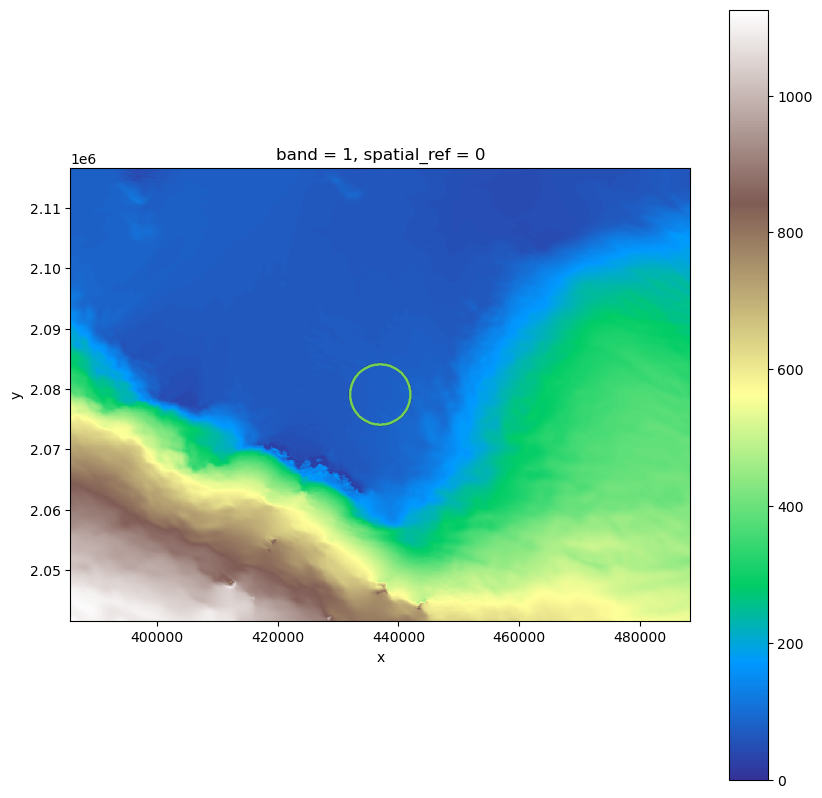

In [7]:
dem.plot(figsize=(10, 10), cmap="terrain",)
circular_mask.plot.contour()
plt.gca().set_aspect('equal') 

In [8]:
from xarray_sweep import xarray_sweep

In [9]:
def vary_melt_magnitude(melt_magnitude):
    return fill_spill_merge(wtd=circular_melt*melt_magnitude, hierarchy=hier).to_dataset(name='fwt')

variable_melt_magnitude = xarray_sweep(vary_melt_magnitude, melt_magnitude = np.linspace(0,.5,300))


  0%|          | 0/300 [00:00<?, ?it/s]

In [10]:
import hvplot.xarray

In [11]:
coarse = variable_melt_magnitude.coarsen(x=2, y=2, boundary = 'trim').mean().fwt
coarse.hvplot(x='x', y = 'y', clim=(0,1))

BokehModel(combine_events=True, render_bundle={'docs_json': {'e2b1e605-e0e2-4e33-a7fd-284679077eb1': {'version…

:DynamicMap   [melt_magnitude]
   :Image   [x,y]   (water depth)

In [12]:
dem.coarsen(x=10, y=10, boundary = 'trim').mean().hvplot(x='x', y='y', cmap='gist_earth',aspect='equal', width = 500)\
    * coarse.where(coarse>0).hvplot(x = 'x',y='y', aspect='equal', clim = (0,1))

BokehModel(combine_events=True, render_bundle={'docs_json': {'fe9bb4bd-a6e4-4edf-becc-42fe6f507360': {'version…

:DynamicMap   [melt_magnitude]
   :Overlay
      .Image.I  :Image   [x,y]   (value)
      .Image.II :Image   [x,y]   (water depth)

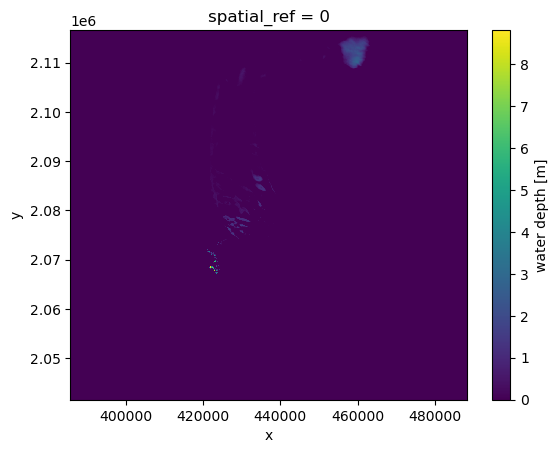

In [13]:
ds = fsm(dem, circular_melt, dh = hier)
ds.water_depth.plot()

In [14]:
ds

<xarray.Dataset> Size: 30MB
Dimensions:                       (x: 1068, y: 781)
Coordinates:
  * x                             (x) float64 9kB 3.858e+05 ... 4.882e+05
    spatial_ref                   int64 8B 0
  * y                             (y) float64 6kB 2.117e+06 ... 2.042e+06
Data variables: (12/16)
    water_depth                   (y, x) float64 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    melt                          (y, x) float64 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dem                           (y, x) float32 3MB 0.0 0.0 0.0 ... 547.5 0.0
    x_com_w                       float64 8B 4.482e+05
    y_com_w                       float64 8B 2.101e+06
    x_com_m                       float64 8B 4.37e+05
    ...                            ...
    accumulation_on_grounded_ice  float64 8B 4.802e+06
    melt_on_grounded_ice          float64 8B 0.0
    water_flow_over_GL            float64 8B -4.802e+06
    grounded_mask                 (y, x) int64 7MB 0 0 0 0 0 0 0 ... 1 1 1 1 1 1
    accumulation_total            float64 8B 7.859e+07
    melt_total                    float64 8B 7.859e+07
Attributes:
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  True
    long_name:                             water depth
    units:                                 m

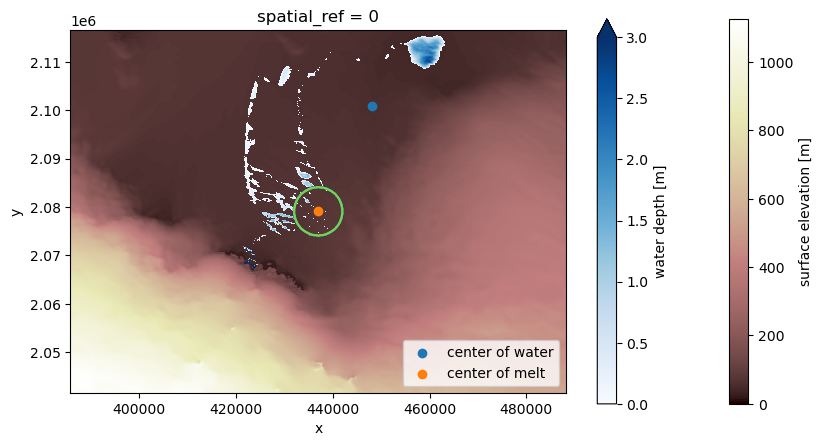

In [15]:
ds.dem.plot(figsize=(10, 5), cmap="pink",)
ds.melt.plot.contour()
ds.water_depth.where(ds.water_depth>0).plot(vmin=0, vmax=3, cmap = 'Blues')
plt.scatter(ds.x_com_w, ds.y_com_w, label = 'center of water')
plt.scatter(ds.x_com_m, ds.y_com_m, label = 'center of melt')
plt.legend(loc = 'lower right')
plt.gca().set_aspect('equal') 